In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams["xtick.direction"] = "in"
matplotlib.rcParams["ytick.direction"] = "in"
plt.rcParams['xtick.major.size'] = 2  # Length of major ticks
plt.rcParams['ytick.major.size'] = 2  # Length of major ticks
plt.rcParams['xtick.minor.size'] = 1  # Length of minor ticks
plt.rcParams['ytick.minor.size'] = 1  # Length of minor ticks

In [3]:
folder = Path("~/Downloads").expanduser()
pc = pd.read_csv(folder / "pc_speed_tensile.csv")
pa = pd.read_csv(folder / "pa_speed_tensile.csv")

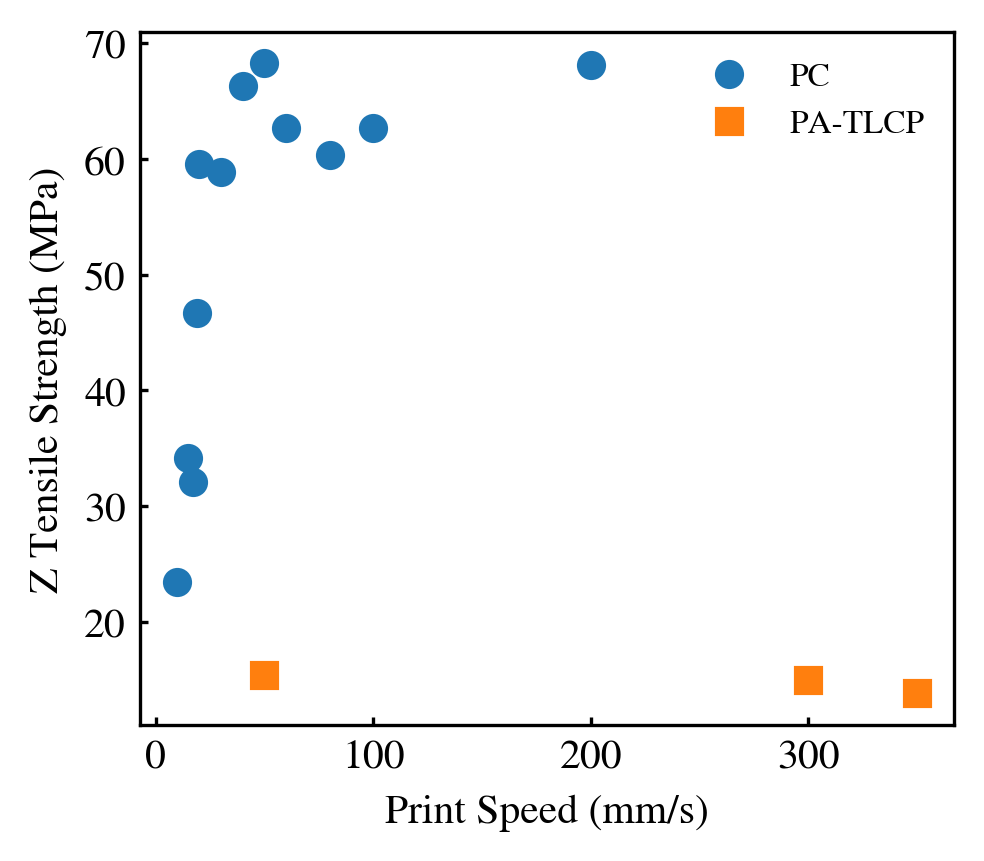

In [11]:
plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(pc["speed"], pc["z_tensile"], label="PC", marker="o", ls="")
plt.plot(pa["speed"], pa["z_tensile"], label="PA-TLCP", marker="s", ls="")
plt.xlabel("Print Speed (mm/s)")
plt.ylabel("Z Tensile Strength (MPa)")
plt.legend(fontsize=8, frameon=False)

(0.0, 10.0)

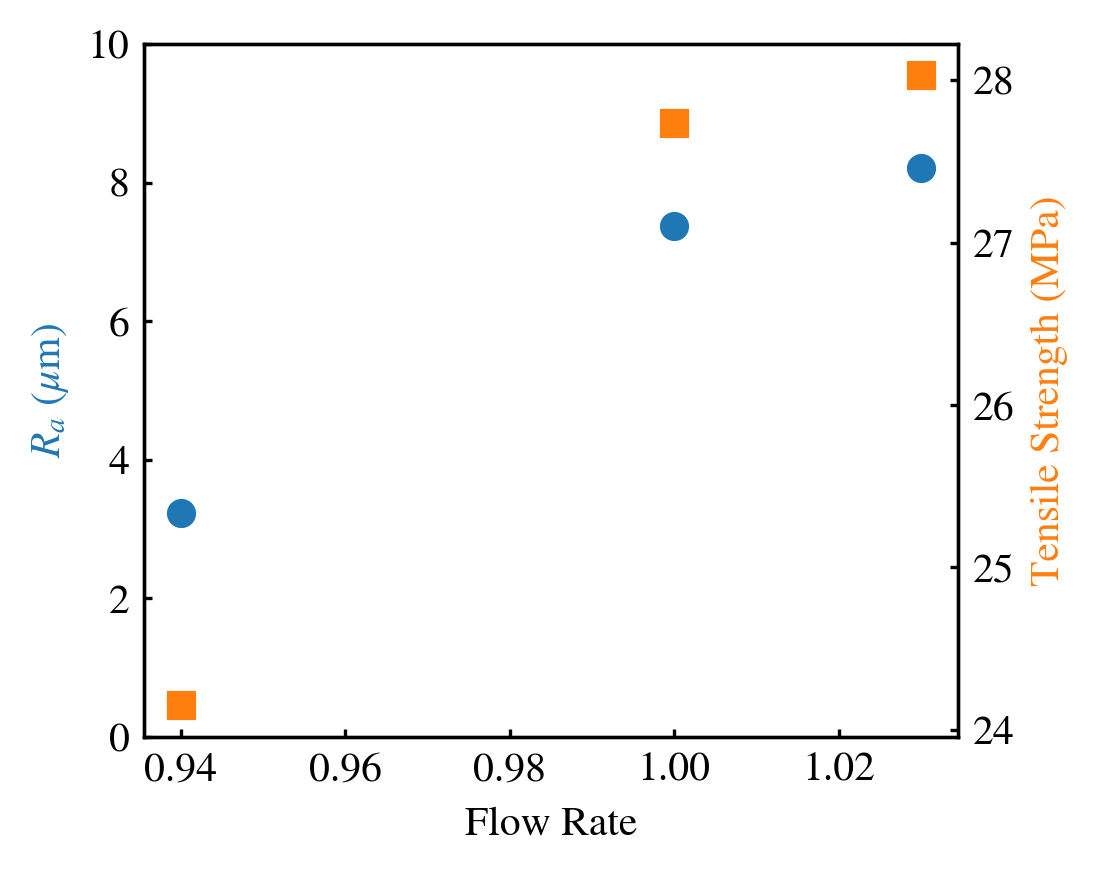

In [14]:
flow = [0.94, 1, 1.03]
ra = [3.23, 7.37, 8.21]
TS = [24.15, 27.74,28.03]

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)
ax.plot(flow, ra, label="RA", marker="o", ls="")
ax2 = ax.twinx()
ax2.plot(flow, TS, label="TS", marker="s", ls="", color=cmap(1))
ax.set_xlabel("Flow Rate")
ax.set_ylabel("$R_a$ ($\\mu$m)", color=cmap(0))
ax2.set_ylabel("Tensile Strength (MPa)", color=cmap(1))
ax.set_ylim(0, 10)

Text(0, 0.5, 'Tensile Strength (MPa)')

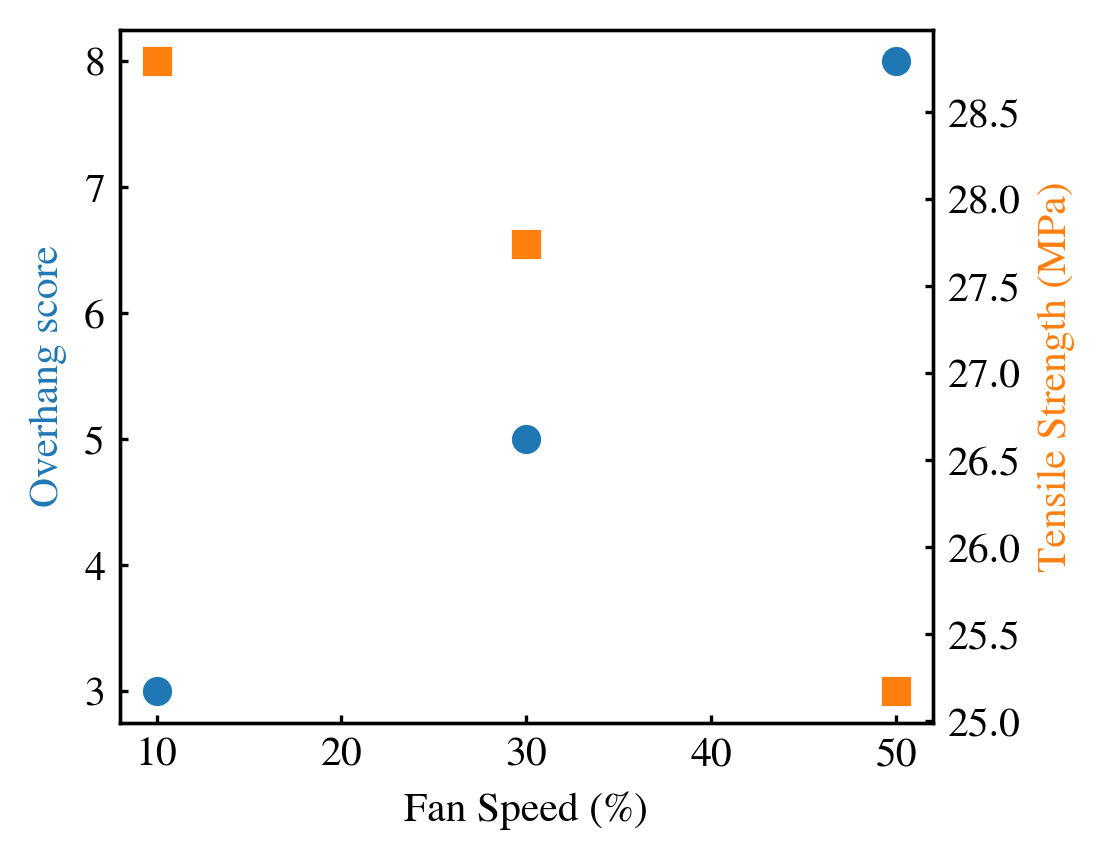

In [16]:
fan = [10, 30, 50]
oh = [3, 5, 8]
ts = [28.79, 27.74, 25.17]

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)
ax.plot(fan, oh, label="OH", marker="o", ls="")
ax2 = ax.twinx()
ax2.plot(fan, ts, label="TS", marker="s", ls="", color=cmap(1))
ax.set_xlabel("Fan Speed (%)")
ax.set_ylabel("Overhang score", color=cmap(0))
ax2.set_ylabel("Tensile Strength (MPa)", color=cmap(1))

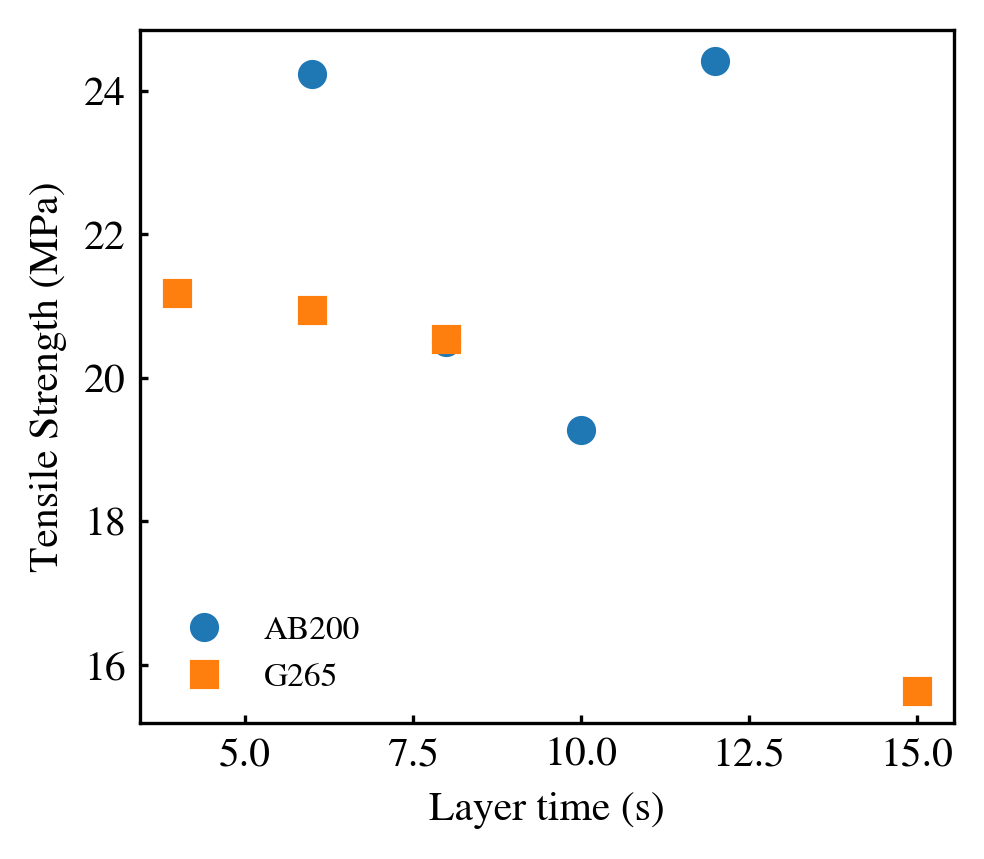

In [20]:
lt = [6, 8, 10, 12]
ts = [24.23, 20.5, 19.28, 24.41]
lt2 = [4, 6, 8, 15]
ts2 = [21.18, 20.95, 20.54, 15.63]


plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(lt, ts, label="AB200", marker="o", ls="")
plt.plot(lt2, ts2, label="G265", marker="s", ls="")
plt.xlabel("Layer time (s)")
plt.ylabel("Tensile Strength (MPa)")
plt.legend(fontsize=8, frameon=False, loc="lower left")

Text(0, 0.5, 'Tensile Strength (MPa)')

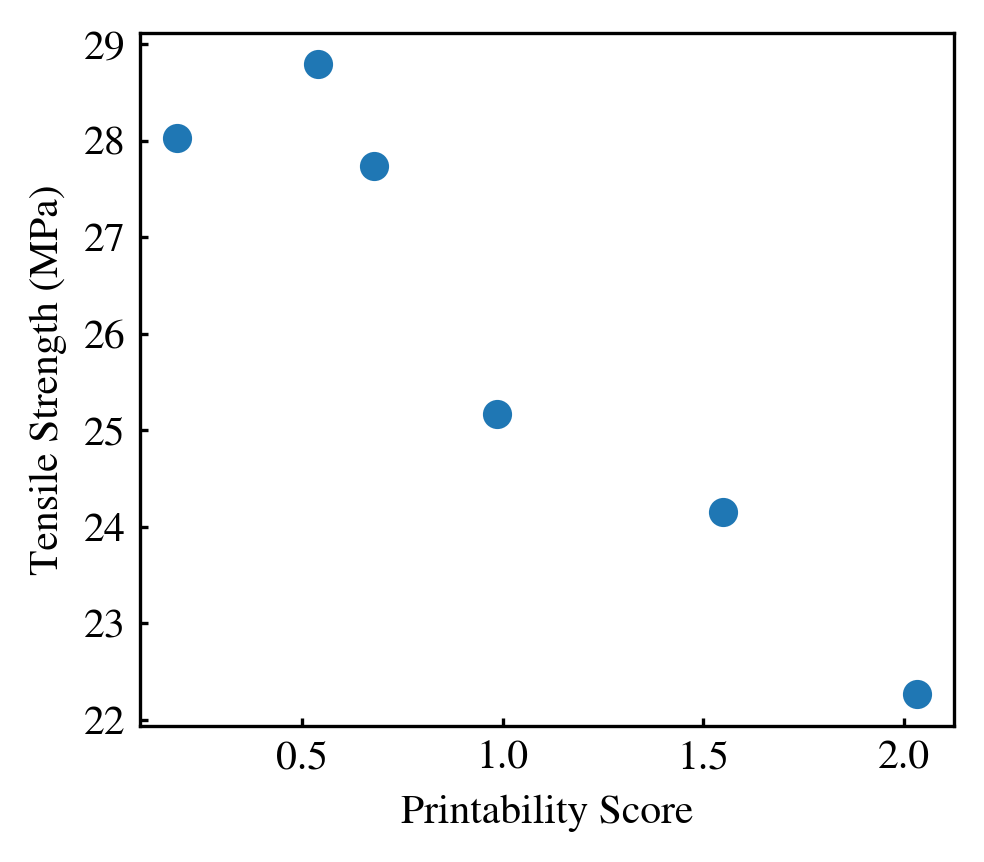

In [6]:
ss = [0.539, 0.189, 0.678, 1.548, 0.986, 2.033]
ts = [28.79, 28.03, 27.74, 24.15, 25.17, 22.26]

plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(ss, ts, marker="o", ls="")
plt.xlabel("Printability Score")
plt.ylabel("Tensile Strength (MPa)")

In [4]:
rho = 1000
g = 9.8
w = 0.42e-3
h = 0.2e-3
la = h / 10
tc = 5

In [5]:
mu = rho * g * w * h * tc / 2 / la

In [7]:
import numpy as np

In [11]:
r = 0.875e-3
30 / np.pi / r ** 2

12472550.642303634

In [12]:
D = 0.4e-3
L = 0.7e-3
Q = 24e-9
dp = 1.2e7
dp * np.pi * D ** 4 / 128 / Q / L

448.7989505128277

(0.0, 80.0)

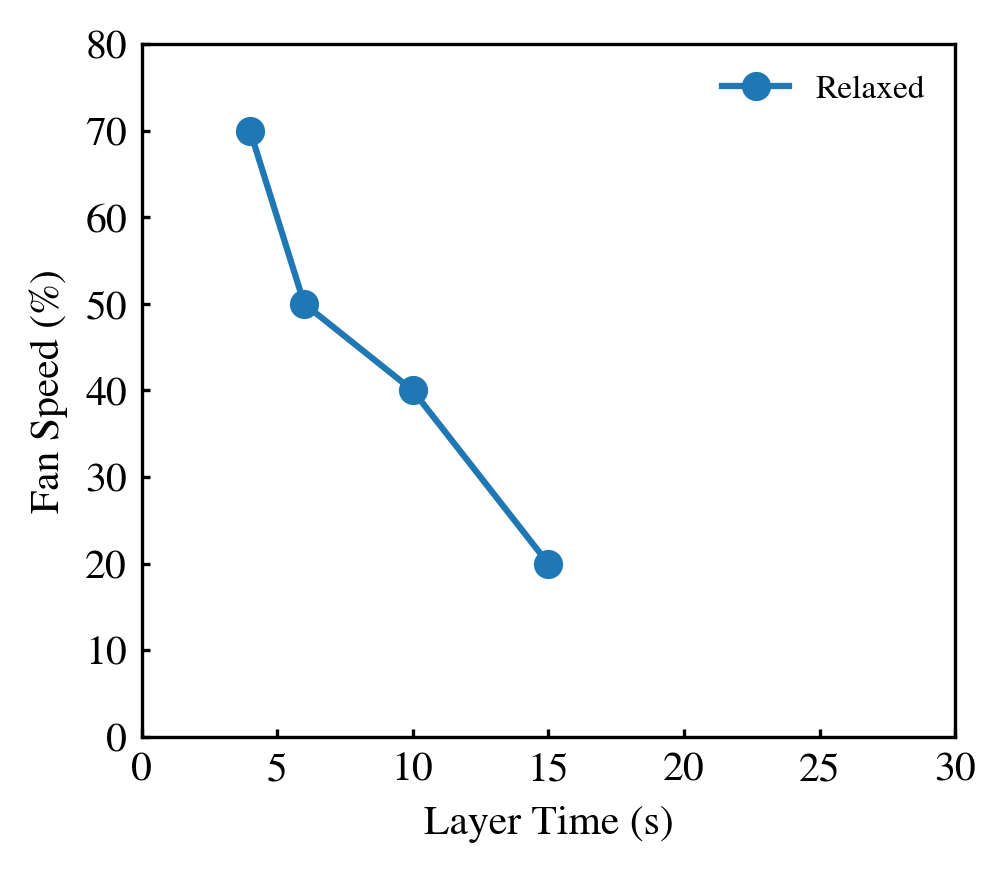

In [4]:
fan_strict = [80, 70, 60, 50, 20, 10]
lt_strict = [4, 6, 8, 10, 15, 30]
fan = [70, 50, 40, 20]
lt = [4, 6, 10, 15]
fan_preset = [30, 10]
lt_preset = [12, 30]

plt.figure(figsize=(3.5, 3), dpi=300)
# plt.plot(lt_strict, fan_strict,label="Strict", marker="o")
plt.plot(lt, fan, label="Relaxed", marker="o")
# plt.plot(lt_preset, fan_preset, label="Preset", marker="o")
plt.xlabel("Layer Time (s)")
plt.ylabel("Fan Speed (%)")
plt.legend(fontsize=8, frameon=False, loc="upper right")
plt.xlim(0, 30)
plt.ylim(0, 80)

## Iso-appearance line overlay on z-tensile data

In [129]:
folder = Path("/Users/zhengyang/Documents/preset_proj")
df = pd.read_csv(folder / "ztensile.csv", usecols=[0,1,2,3,4,5,7])

In [130]:
df

,材料,层时间（s）,风扇开度（%）,拉伸强度（MPa）,拉伸强度标准差（MPa）,等分线判定标准,打印机型号
0,AB200,4,80,25.19,0.22,Strict,H2D
1,AB200,6,70,24.23,0.85,Strict,H2D
2,AB200,8,60,20.5,0.49,Strict,H2D
3,AB200,10,50,19.28,0.82,Strict,H2D
4,AB200,15,20,21.19,0.23,Strict,H2D
5,AB200,15,20,21.19,0.23,Relaxed,H2D
6,AB200,4,70,26.44,0.68,Relaxed,H2D
7,AB200,6,50,25.94,0.18,Relaxed,H2D
8,AB200,8,50,23.4,0.4,Relaxed,H2D
9,AB200,10,40,23.05,0.25,Relaxed,H2D


In [131]:
df_ab = df.loc[(df["材料"]=="C525") & (df["打印机型号"]=="H2C")]
ab_strict = df_ab.loc[df_ab["等分线判定标准"]=="Strict"].sort_values(by=["层时间（s）"])
ab_relaxed = df_ab.loc[df_ab["等分线判定标准"]=="Relaxed"].sort_values(by=["层时间（s）"])

In [132]:
data = df_ab.values[:, 1:4].astype(float)

In [138]:
data

array([[ 4.  , 80.  , 38.44],
       [ 6.  , 60.  , 30.79],
       [ 8.  , 40.  , 30.03],
       [15.  , 20.  , 30.29],
       [15.  , 20.  , 30.29],
       [ 4.  , 60.  , 36.84],
       [ 6.  , 40.  , 31.6 ]])

In [133]:
x, y, z = data[:, 0], data[:, 1], data[:, 2]

from scipy.interpolate import LinearNDInterpolator
import numpy as np
# fill_value=0：凸包（数据边界）之外的点直接返回 0，不做外推
interp = LinearNDInterpolator(list(zip(x, y)), z, fill_value=0.0)

In [139]:
xx, yy = np.meshgrid(np.linspace(x.min(), x.max(), 1000), np.linspace(y.min(), y.max(), 1000))
zz = interp(xx, yy)

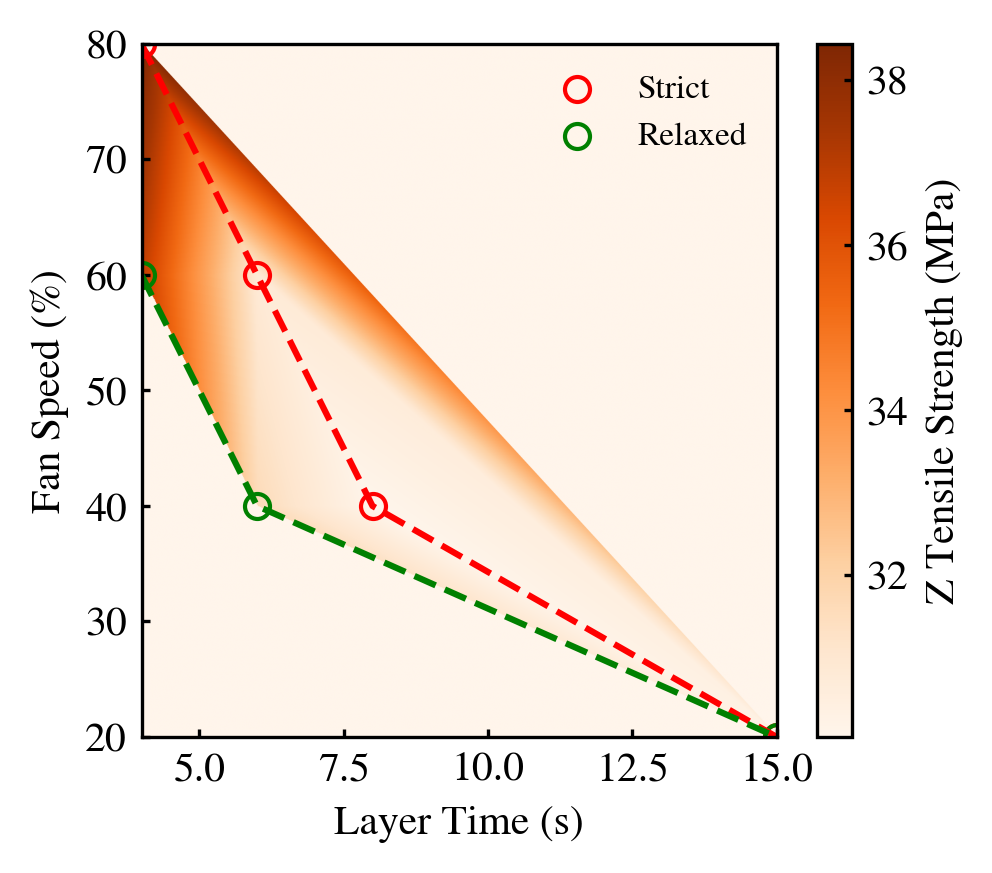

In [140]:
plt.figure(figsize=(3.5, 3), dpi=300)
plt.imshow(zz, vmin=z.min(), vmax=z.max(), 
           cmap="Oranges", origin="lower", 
           extent=[x.min(), x.max(), y.min(), y.max()],
           aspect=0.20)
plt.colorbar(label="Z Tensile Strength (MPa)")
plt.xlabel("Layer Time (s)")
plt.ylabel("Fan Speed (%)")
plt.scatter(ab_strict["层时间（s）"], ab_strict["风扇开度（%）"], label="Strict", marker="o", edgecolor="red", facecolor=(0,0,0,0))
plt.scatter(ab_relaxed["层时间（s）"], ab_relaxed["风扇开度（%）"], label="Relaxed", marker="o", edgecolor="green", facecolor=(0,0,0,0))
plt.plot(ab_strict["层时间（s）"], ab_strict["风扇开度（%）"], color="red", ls="--")
plt.plot(ab_relaxed["层时间（s）"], ab_relaxed["风扇开度（%）"], color="green", ls="--")
plt.legend(fontsize=8, frameon=False, loc="upper right")